In [1]:
## Phase 1 — Implémentation de l'environnement et récupération des données/rendements log

In [2]:
import yfinance as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Récupération des 5 dernières années de prix STM (coté au NYSE)
stm = sf.Ticker("STM")
data = stm.history(period="5y")

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-09-16 00:00:00-04:00,44.948852,45.437950,44.862541,45.265327,1967500,0.00,0.0
2021-09-17 00:00:00-04:00,44.296712,44.392615,43.443192,43.980240,2936400,0.00,0.0
2021-09-20 00:00:00-04:00,42.453417,43.067987,42.309379,42.971962,2451200,0.06,0.0
2021-09-21 00:00:00-04:00,43.740183,43.759389,43.250449,43.471310,1223800,0.00,0.0
2021-09-22 00:00:00-04:00,43.567332,44.124289,43.500114,43.980247,1277600,0.00,0.0


In [3]:
# On ne garde que le prix de clôture, c'est la référence standard pour calculer des rendements
close_prices = data["Close"]

# Rendement journalier logarithmique : log(prix aujourd'hui / prix hier)
log_returns = np.log(close_prices / close_prices.shift(1))

# La première ligne est vide (pas de "hier" pour le tout premier jour) donc on la retire
log_returns = log_returns.dropna()

log_returns.describe()

count    1254.000000
mean        0.000062
std         0.029980
min        -0.206669
25%        -0.015607
50%         0.000222
75%         0.016217
max         0.194619
Name: Close, dtype: float64

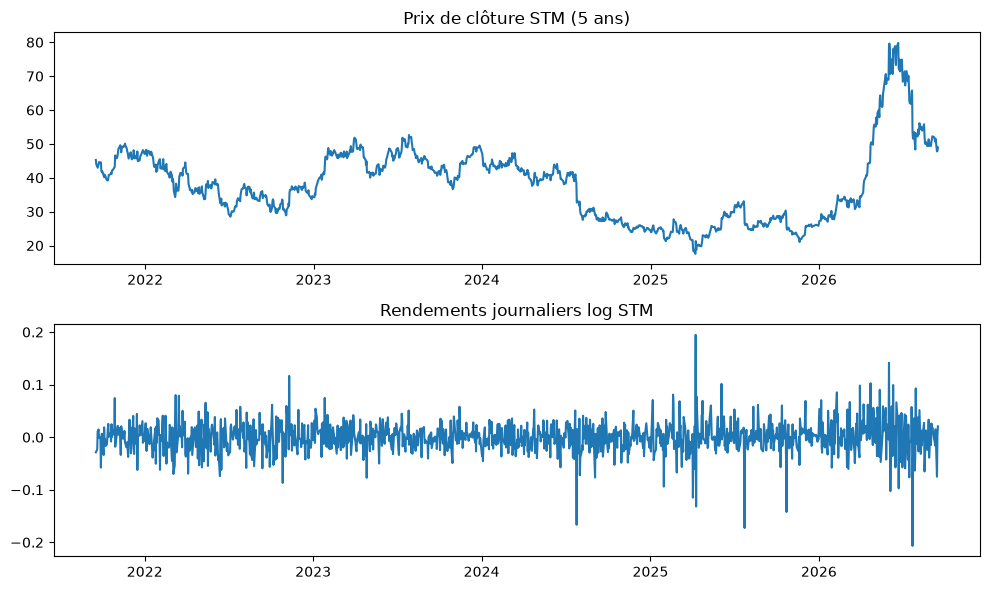

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(close_prices)
axes[0].set_title("Prix de clôture STM (5 ans)")

axes[1].plot(log_returns)
axes[1].set_title("Rendements journaliers log STM")

plt.tight_layout()
plt.show()

In [5]:
##Phase 2A - Pricer Black-Scholes

In [6]:
from scipy.stats import norm

def d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

In [7]:
def bs_call_price(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price

In [8]:
print(bs_call_price(S=100, K=100, T=1, r=0.03, sigma=0.47))

19.81889331666021


In [9]:
def bs_put_price(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

In [10]:
print(bs_put_price(S=100, K=100, T=1, r=0.03, sigma=0.47))

16.863446671511035


In [11]:
##Phase 2B - Pricer Monte Carlo

In [12]:
def simulate_terminal_prices(S, T, r, sigma, n_sims):
    Z = np.random.standard_normal(n_sims)
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    return S_T

In [13]:
np.random.seed(42)  # pour reproductibilité
prix_simules = simulate_terminal_prices(S=100, T=1, r=0.03, sigma=0.47, n_sims=10000)
print(prix_simules[:5])  # affiche les 5 premiers
print(prix_simules.mean())

[116.53315653  86.46467633 125.10254974 188.77280811  82.65440335]
103.028597454253


In [14]:
def mc_call_price(S, K, T, r, sigma, n_sims):
    S_T = simulate_terminal_prices(S, T, r, sigma, n_sims)
    payoffs = np.maximum(S_T - K, 0)
    price = np.exp(-r * T) * payoffs.mean()
    return price

In [15]:
print(mc_call_price(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000))
print(bs_call_price(S=100, K=100, T=1, r=0.03, sigma=0.47))

19.87864694199049
19.81889331666021


In [16]:
def mc_put_price(S, K, T, r, sigma, n_sims):
    S_T = simulate_terminal_prices(S, T, r, sigma, n_sims)
    payoffs = np.maximum(K - S_T, 0)
    price = np.exp(-r * T) * payoffs.mean()
    return price

In [17]:
print(mc_put_price(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000))
print(bs_put_price(S=100, K=100, T=1, r=0.03, sigma=0.47))

16.879012001226616
16.863446671511035


In [18]:
##Phase 2C - Test de convergence Monte Carlo vs Black-Scholes

In [19]:
def mc_call_price_with_error(S, K, T, r, sigma, n_sims):
    S_T = simulate_terminal_prices(S, T, r, sigma, n_sims)
    payoffs = np.exp(-r * T) * np.maximum(S_T - K, 0)
    price = payoffs.mean()
    std_error = payoffs.std() / np.sqrt(n_sims)
    return price, std_error

In [20]:
price, se = mc_call_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
print(f"Prix MC: {price:.4f} ± {se:.4f}")
print(f"Prix BS: {bs_call_price(S=100, K=100, T=1, r=0.03, sigma=0.47):.4f}")

Prix MC: 19.7853 ± 0.1181
Prix BS: 19.8189


In [21]:
def mc_put_price_with_error(S, K, T, r, sigma, n_sims):
    S_T = simulate_terminal_prices(S, T, r, sigma, n_sims)
    payoffs = np.exp(-r * T) * np.maximum(K - S_T, 0)
    price = payoffs.mean()
    std_error = payoffs.std() / np.sqrt(n_sims)
    return price, std_error

In [22]:
price, se = mc_put_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
print(f"Prix MC: {price:.4f} ± {se:.4f}")
print(f"Prix BS: {bs_put_price(S=100, K=100, T=1, r=0.03, sigma=0.47):.4f}")

Prix MC: 16.8837 ± 0.0630
Prix BS: 16.8634


In [23]:
n_sims_list = [100, 1000, 10000, 100000, 1000000]

call_results = [mc_call_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=n) for n in n_sims_list]
put_results = [mc_put_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=n) for n in n_sims_list]

call_prices = [r[0] for r in call_results]
call_errors = [r[1] for r in call_results]
put_prices = [r[0] for r in put_results]
put_errors = [r[1] for r in put_results]

for n, p, e in zip(n_sims_list, call_prices, call_errors):
    print(f"n={n:>8} | call = {p:.4f} ± {e:.4f}")
for n, p, e in zip(n_sims_list, put_prices, put_errors):
    print(f"n={n:>8} | put  = {p:.4f} ± {e:.4f}")

n=     100 | call = 23.5643 ± 4.0689
n=    1000 | call = 20.6836 ± 1.2245
n=   10000 | call = 19.4118 ± 0.3651
n=  100000 | call = 19.7766 ± 0.1192
n= 1000000 | call = 19.7988 ± 0.0375
n=     100 | put  = 18.9026 ± 2.0350
n=    1000 | put  = 17.0802 ± 0.6289
n=   10000 | put  = 16.9097 ± 0.1974
n=  100000 | put  = 16.8588 ± 0.0629
n= 1000000 | put  = 16.8451 ± 0.0199


In [24]:
##Variables antithétiques pour réduire la variance

In [25]:
def simulate_terminal_prices_antithetic(S, T, r, sigma, n_sims):
    n_half = n_sims // 2
    Z = np.random.standard_normal(n_half)
    Z_antithetic = np.concatenate([Z, -Z])
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_antithetic)
    return S_T

In [26]:
def mc_call_price_antithetic(S, K, T, r, sigma, n_sims):
    n_half = n_sims // 2
    Z = np.random.standard_normal(n_half)
    S_T_up = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    S_T_down = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * (-Z))
    payoff_up = np.exp(-r * T) * np.maximum(S_T_up - K, 0)
    payoff_down = np.exp(-r * T) * np.maximum(S_T_down - K, 0)
    pair_avg = (payoff_up + payoff_down) / 2
    price = pair_avg.mean()
    std_error = pair_avg.std() / np.sqrt(n_half)
    return price, std_error

In [27]:
def mc_put_price_antithetic(S, K, T, r, sigma, n_sims):
    n_half = n_sims // 2
    Z = np.random.standard_normal(n_half)
    S_T_up = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    S_T_down = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * (-Z))
    payoff_up = np.exp(-r * T) * np.maximum(K - S_T_up, 0)
    payoff_down = np.exp(-r * T) * np.maximum(K - S_T_down, 0)
    pair_avg = (payoff_up + payoff_down) / 2
    price = pair_avg.mean()
    std_error = pair_avg.std() / np.sqrt(n_half)
    return price, std_error

In [28]:
price_std, se_std = mc_call_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
price_anti, se_anti = mc_call_price_antithetic(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
print(f"Call standard     : {price_std:.4f} ± {se_std:.4f}")
print(f"Call antithétique : {price_anti:.4f} ± {se_anti:.4f}")

price_std_p, se_std_p = mc_put_price_with_error(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
price_anti_p, se_anti_p = mc_put_price_antithetic(S=100, K=100, T=1, r=0.03, sigma=0.47, n_sims=100000)
print(f"Put standard      : {price_std_p:.4f} ± {se_std_p:.4f}")
print(f"Put antithétique  : {price_anti_p:.4f} ± {se_anti_p:.4f}")

Call standard     : 19.5181 ± 0.1170
Call antithétique : 19.8312 ± 0.1005
Put standard      : 16.8129 ± 0.0629
Put antithétique  : 16.8797 ± 0.0342


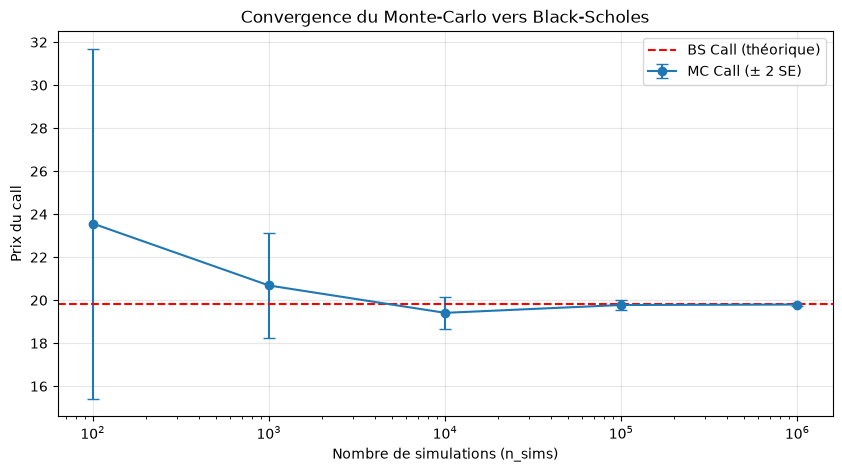

In [29]:
plt.figure(figsize=(10, 5))
plt.errorbar(n_sims_list, call_prices, yerr=[2*e for e in call_errors], fmt='o-', label='MC Call (± 2 SE)', capsize=4)
plt.axhline(y=bs_call_price(S=100, K=100, T=1, r=0.03, sigma=0.47), color='red', linestyle='--', label='BS Call (théorique)')
plt.xscale('log')
plt.xlabel('Nombre de simulations (n_sims)')
plt.ylabel('Prix du call')
plt.title('Convergence du Monte-Carlo vers Black-Scholes')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("fig1_convergence_mc_bs.png", dpi=150, bbox_inches='tight')
plt.show()

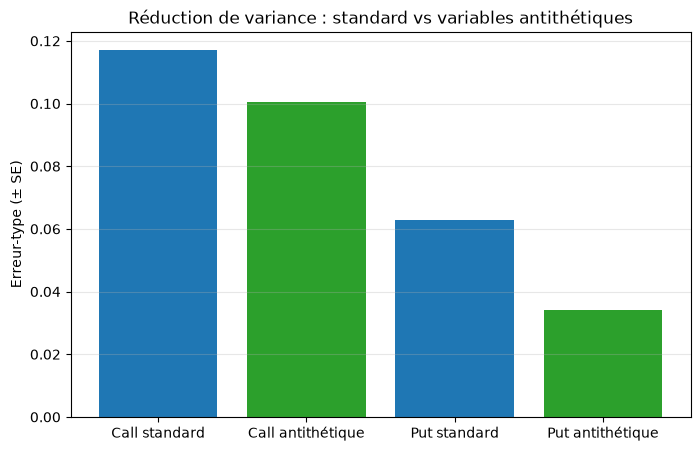

In [30]:
categories = ['Call standard', 'Call antithétique', 'Put standard', 'Put antithétique']
errors = [se_std, se_anti, se_std_p, se_anti_p]
colors = ['#1f77b4', '#2ca02c', '#1f77b4', '#2ca02c']

plt.figure(figsize=(8, 5))
plt.bar(categories, errors, color=colors)
plt.ylabel('Erreur-type (± SE)')
plt.title('Réduction de variance : standard vs variables antithétiques')
plt.grid(alpha=0.3, axis='y')
plt.show()

In [31]:
## Phase 2D - Greeks

In [32]:
def bs_delta(S, K, T, r, sigma, option_type='call'):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    if option_type == 'call':
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1

In [33]:
print(bs_delta(S=100, K=100, T=1, r=0.03, sigma=0.47, option_type='call'))
print(bs_delta(S=100, K=100, T=1, r=0.03, sigma=0.47, option_type='put'))

0.617465039050488
-0.382534960949512


In [34]:
def bs_gamma(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

In [35]:
print(bs_gamma(S=100, K=100, T=1, r=0.03, sigma=0.47))
print(bs_vega(S=100, K=100, T=1, r=0.03, sigma=0.47) / 100)  # Vega pour 1% de vol

0.008117478068195487
0.38152146920518787


In [36]:
## Phase 3A - Volatilité historique en rolling window

In [37]:
window_short = 63    # ~3 mois en jours de bourse (21 jours ouvrés/mois × 3)
window_long = 504    # ~2 ans en jours de bourse (252 jours ouvrés/an × 2)

In [38]:
vol_short = log_returns.rolling(window_short).std() * np.sqrt(252)
vol_long = log_returns.rolling(window_long).std() * np.sqrt(252)

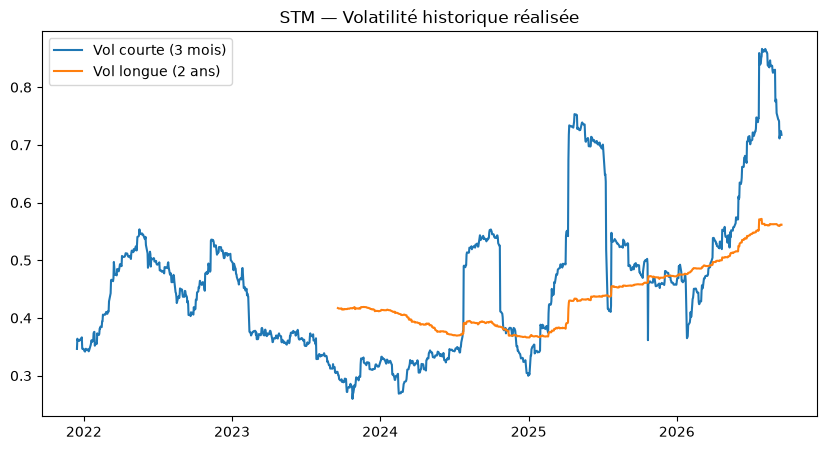

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(vol_short, label="Vol courte (3 mois)")
plt.plot(vol_long, label="Vol longue (2 ans)")
plt.legend()
plt.title("STM — Volatilité historique réalisée")
plt.show()

In [40]:
## Phase 3B - Bootstrap sur rendements pour obtenir CI vol historique

In [41]:
n_bootstrap = 10000
bootstrap_vols = []

for _ in range(n_bootstrap):
    sample = log_returns.sample(n=len(log_returns), replace=True)
    vol_annual = sample.std() * np.sqrt(252)
    bootstrap_vols.append(vol_annual)

bootstrap_vols = np.array(bootstrap_vols)
ci_lower, ci_upper = np.percentile(bootstrap_vols, [2.5, 97.5])
print(f"Vol historique ponctuelle : {log_returns.std() * np.sqrt(252):.2%}")
print(f"Intervalle de confiance à 95% (bootstrap) : [{ci_lower:.2%}, {ci_upper:.2%}]")

Vol historique ponctuelle : 47.59%
Intervalle de confiance à 95% (bootstrap) : [43.96%, 51.43%]


In [42]:
## Phase 3C- IV vs Vol Historique

In [43]:
expirations = stm.options
print(expirations)

('2026-09-18', '2026-09-25', '2026-10-02', '2026-10-09', '2026-10-16', '2026-10-23', '2026-10-30', '2026-11-20', '2027-01-15', '2027-04-16', '2027-11-19', '2028-01-21')


In [44]:
expiry = "2026-11-20"
chain = stm.option_chain(expiry)
calls = chain.calls

spot_price = stm.history(period="1d")['Close'].iloc[-1]

# Note : openInterest s'est révélé non fiable sur STM (quasi toujours à 0
# malgré du volume réel), filtre basé sur volume à la place
calls_liquid = calls[calls['volume'] > 0].sort_values('volume', ascending=False)
strike_atm = calls_liquid.iloc[0]['strike']
market_price = calls_liquid.iloc[0]['lastPrice']

print(f"Spot STM : {spot_price:.2f}")
print(f"Strike ATM retenu : {strike_atm}, prix marché : {market_price}")

Spot STM : 48.90
Strike ATM retenu : 55.0, prix marché : 2.5


In [45]:
# IV yfinance peu fiable donc inversion BS avec K=50 (gros volume)

In [46]:
from scipy.optimize import brentq
from datetime import datetime

expiry_date = datetime.strptime(expiry, "%Y-%m-%d")
T = (expiry_date - datetime.now()).days / 365
r = 0.03

# Note : impliedVolatility de Yahoo s'est révélée incohérente sur cette
# chaîne (valeurs aberrantes même sur strikes liquides) donc inversion manuelle
def objective(sigma):
    return bs_call_price(spot_price, strike_atm, T, r, sigma) - market_price

implied_vol = brentq(objective, 0.01, 3.0)
print(f"IV calculée : {implied_vol:.2%}")

IV calculée : 56.39%


In [47]:
rv_historical = log_returns.std() * np.sqrt(252)
print(f"Vol réalisée (historique) : {rv_historical:.2%}")
print(f"IV (implicite, marché) : {implied_vol:.2%}")
print(f"Écart IV - RV : {(implied_vol - rv_historical):.2%}")

Vol réalisée (historique) : 47.59%
IV (implicite, marché) : 56.39%
Écart IV - RV : 8.79%


In [48]:
# Term Structure

In [49]:
def get_iv_atm(ticker_obj, expiry_str, spot, r=0.03):
    chain = ticker_obj.option_chain(expiry_str)
    calls = chain.calls
    calls_liquid = calls[calls['volume'] > 0].sort_values('volume', ascending=False)
    
    if len(calls_liquid) == 0:
        return None, None, None
    
    strike = calls_liquid.iloc[0]['strike']
    price = calls_liquid.iloc[0]['lastPrice']
    
    expiry_date = datetime.strptime(expiry_str, "%Y-%m-%d")
    T = (expiry_date - datetime.now()).days / 365
    
    def objective(sigma):
        return bs_call_price(spot, strike, T, r, sigma) - price
    
    try:
        iv = brentq(objective, 0.01, 3.0)
    except ValueError:
        return None, None, None
    
    return iv, T, strike

In [50]:
iv_test, T_test, strike_test = get_iv_atm(stm, "2026-11-20", spot_price)
print(f"IV: {iv_test:.2%}, T: {T_test:.4f}, strike: {strike_test}")

IV: 56.39%, T: 0.1753, strike: 55.0


In [51]:
expiries_to_test = ["2026-09-25", "2026-10-16", "2026-11-20", "2027-01-15", "2027-04-16"]

term_structure = []

for exp in expiries_to_test:
    iv, T, strike = get_iv_atm(stm, exp, spot_price)
    if iv is not None:
        term_structure.append({"expiry": exp, "T": T, "strike": strike, "iv": iv})

term_structure_df = pd.DataFrame(term_structure)
term_structure_df

,expiry,T,strike,iv
0,2026-09-25,0.021918,55.0,0.507138
1,2026-10-16,0.079452,100.0,0.980912
2,2026-11-20,0.175342,55.0,0.563854
3,2027-01-15,0.328767,55.0,0.553150
4,2027-04-16,0.578082,55.0,0.523797


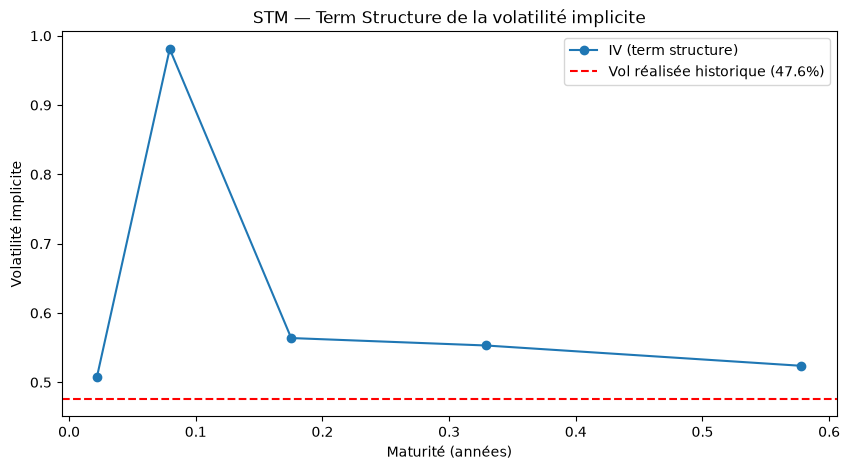

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(term_structure_df['T'], term_structure_df['iv'], marker='o', label='IV (term structure)')
plt.axhline(y=rv_historical, color='red', linestyle='--', label=f'Vol réalisée historique ({rv_historical:.1%})')
plt.xlabel("Maturité (années)")
plt.ylabel("Volatilité implicite")
plt.title("STM — Term Structure de la volatilité implicite")
plt.legend()
plt.savefig("fig2_term_structure_iv.png", dpi=150, bbox_inches='tight')
plt.show()

In [53]:
## Phase 4A - Pricing Phoenix par Monte-Carlo

In [54]:
S0 = spot_price

In [55]:
# Paramètres du produit structuré (Phoenix Autocall)
note_S0 = S0                    # niveau initial = spot actuel STM
note_T = 2.0                    # maturité en années
n_obs = 4                       # nombre d'observations (semestrielles)
obs_dates = [0.5 * i for i in range(1, n_obs + 1)]  # [0.5, 1.0, 1.5, 2.0]

autocall_barrier = 1.00         # 100% de S0
coupon_barrier = 0.70           # 70% de S0
protection_barrier = 0.60       # 60% de S0
coupon_rate = 0.08              # 8% par observation si coupon versé

In [56]:
def simulate_obs_paths(S0, r, sigma, obs_dates, n_sims, seed=42):
    np.random.seed(seed)
    n_obs = len(obs_dates)
    paths = np.zeros((n_sims, n_obs))
    dt = np.diff([0] + obs_dates)  # durée entre chaque observation

    S_current = np.full(n_sims, S0)
    for i, tau in enumerate(dt):
        Z = np.random.standard_normal(n_sims)
        S_current = S_current * np.exp((r - 0.5 * sigma**2) * tau + sigma * np.sqrt(tau) * Z)
        paths[:, i] = S_current

    return paths

In [57]:
def price_autocall(paths, note_S0, obs_dates, coupon_rate,
                    autocall_barrier, coupon_barrier, protection_barrier, r):
    n_sims, n_obs = paths.shape
    payoffs = np.zeros(n_sims)
    called = np.full(n_sims, False)

    for i in range(n_obs):
        still_active = ~called
        level = paths[:, i] / note_S0

        coupon_paid = still_active & (level >= coupon_barrier)
        payoffs[coupon_paid] += coupon_rate * np.exp(-r * obs_dates[i])

        just_called = still_active & (level >= autocall_barrier)
        payoffs[just_called] += 1.0 * np.exp(-r * obs_dates[i])
        called = called | just_called

    never_called = ~called
    final_level = paths[:, -1] / note_S0
    capital_repaid = np.where(final_level >= protection_barrier, 1.0, final_level)
    payoffs[never_called] += capital_repaid[never_called] * np.exp(-r * obs_dates[-1])

    return payoffs

In [58]:
def note_price_with_error(payoffs):
    price = np.mean(payoffs)
    std_error = np.std(payoffs) / np.sqrt(len(payoffs))
    return price, std_error

n_sims = 100000
paths = simulate_obs_paths(note_S0, r, implied_vol, obs_dates, n_sims)
payoffs = price_autocall(paths, note_S0, obs_dates, coupon_rate,
                          autocall_barrier, coupon_barrier, protection_barrier, r)

price, err = note_price_with_error(payoffs)
print(f"Prix de la note : {price:.4f} (soit {price*100:.2f}% du nominal)")
print(f"Erreur-type : {err:.4f}")
print(f"IC 95% : [{price - 1.96*err:.4f}, {price + 1.96*err:.4f}]")

Prix de la note : 0.8996 (soit 89.96% du nominal)
Erreur-type : 0.0010
IC 95% : [0.8976, 0.9016]


In [59]:
## Phase 4B - Stress-test : Choc de volatilité (vol*2)

In [60]:
def call_loss_probabilities(paths, note_S0, obs_dates, autocall_barrier, protection_barrier):
    n_sims, n_obs = paths.shape
    called = np.full(n_sims, False)
    for i in range(n_obs):
        level = paths[:, i] / note_S0
        called = called | ((~called) & (level >= autocall_barrier))
    prob_called = called.mean()
    final_level = paths[:, -1] / note_S0
    prob_loss = (~called & (final_level < protection_barrier)).mean()
    return prob_called, prob_loss

sigma_stress = implied_vol * 2
paths_stress = simulate_obs_paths(note_S0, r, sigma_stress, obs_dates, n_sims)
payoffs_stress = price_autocall(paths_stress, note_S0, obs_dates, coupon_rate,
                                 autocall_barrier, coupon_barrier, protection_barrier, r)
price_stress, err_stress = note_price_with_error(payoffs_stress)

prob_called_base, prob_loss_base = call_loss_probabilities(paths, note_S0, obs_dates, autocall_barrier, protection_barrier)
prob_called_stress, prob_loss_stress = call_loss_probabilities(paths_stress, note_S0, obs_dates, autocall_barrier, protection_barrier)

print(f"Prix de base (IV={implied_vol:.1%})   : {price:.4f}")
print(f"Prix stressé (vol={sigma_stress:.1%}) : {price_stress:.4f}  ({(price_stress-price)*100:+.2f} pts)")
print(f"P(rappelé) base vs stress   : {prob_called_base:.1%} → {prob_called_stress:.1%}")
print(f"P(perte capital) base vs stress : {prob_loss_base:.1%} → {prob_loss_stress:.1%}")

Prix de base (IV=56.4%)   : 0.8996
Prix stressé (vol=112.8%) : 0.6562  (-24.33 pts)
P(rappelé) base vs stress   : 63.3% → 50.2%
P(perte capital) base vs stress : 26.9% → 46.4%


In [61]:
## Phase 4C - Trouver coupon rate pour lequel prix note vaut 100% nominal

In [62]:
def pricing_gap(coupon_rate_test, paths, note_S0, obs_dates,
                 autocall_barrier, coupon_barrier, protection_barrier, r):
    payoffs_test = price_autocall(paths, note_S0, obs_dates, coupon_rate_test,
                                   autocall_barrier, coupon_barrier, protection_barrier, r)
    return payoffs_test.mean() - 1.0

In [63]:
coupon_rate_par = brentq(
    pricing_gap, 0.0, 0.50,
    args=(paths, note_S0, obs_dates, autocall_barrier, coupon_barrier, protection_barrier, r)
)

payoffs_par = price_autocall(paths, note_S0, obs_dates, coupon_rate_par,
                              autocall_barrier, coupon_barrier, protection_barrier, r)
price_par, err_par = note_price_with_error(payoffs_par)

print(f"Coupon initial testé : {coupon_rate:.2%}  → prix {price:.4f}")
print(f"Coupon calibré au pair : {coupon_rate_par:.2%}  → prix {price_par:.4f}")

Coupon initial testé : 8.00%  → prix 0.8996
Coupon calibré au pair : 16.09%  → prix 1.0000


In [64]:
def price_autocall_decomposed(paths, note_S0, obs_dates, coupon_rate,
                                autocall_barrier, coupon_barrier, protection_barrier, r):
    n_sims, n_obs = paths.shape
    coupon_payoffs = np.zeros(n_sims)
    principal_payoffs = np.zeros(n_sims)
    called = np.full(n_sims, False)

    for i in range(n_obs):
        still_active = ~called
        level = paths[:, i] / note_S0
        coupon_paid = still_active & (level >= coupon_barrier)
        coupon_payoffs[coupon_paid] += coupon_rate * np.exp(-r * obs_dates[i])
        just_called = still_active & (level >= autocall_barrier)
        principal_payoffs[just_called] += 1.0 * np.exp(-r * obs_dates[i])
        called = called | just_called

    never_called = ~called
    final_level = paths[:, -1] / note_S0
    capital_repaid = np.where(final_level >= protection_barrier, 1.0, final_level)
    principal_payoffs[never_called] += capital_repaid[never_called] * np.exp(-r * obs_dates[-1])
    return coupon_payoffs, principal_payoffs

In [65]:
coupon_payoffs_par, principal_payoffs_par = price_autocall_decomposed(
    paths, note_S0, obs_dates, coupon_rate_par,
    autocall_barrier, coupon_barrier, protection_barrier, r)

value_coupons_par = coupon_payoffs_par.mean()
value_principal_par = principal_payoffs_par.mean()
bond_floor = np.exp(-r * note_T)

print(f"Sur 100€ investis, au coupon calibré ({coupon_rate_par:.2%}) :")
print(f"  Valeur des coupons (partie optionnelle 'digitale')      : {value_coupons_par*100:.2f}€")
print(f"  Valeur du remboursement du principal (oblig - put vendu) : {value_principal_par*100:.2f}€")
print(f"  Total (doit valoir ~100€ par construction)               : {(value_coupons_par+value_principal_par)*100:.2f}€")
print(f"  Rappel — obligation ZC pure sans risque                  : {bond_floor*100:.2f}€")
print(f"  → 'Coût net' du risque de capital (put vendu implicite)  : {(bond_floor - value_principal_par)*100:.2f}€")

Sur 100€ investis, au coupon calibré (16.09%) :
  Valeur des coupons (partie optionnelle 'digitale')      : 19.97€
  Valeur du remboursement du principal (oblig - put vendu) : 80.03€
  Total (doit valoir ~100€ par construction)               : 100.00€
  Rappel — obligation ZC pure sans risque                  : 94.18€
  → 'Coût net' du risque de capital (put vendu implicite)  : 14.15€


In [66]:
## Phase 5A - Couple Theta-Gamma pour Delta-Hedging

In [67]:
from datetime import datetime
expiry_1120 = datetime(2026, 11, 20)
T_1120 = (expiry_1120 - datetime.now()).days / 365

In [68]:
def bs_call_theta(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    return -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

def bs_put_theta(S, K, T, r, sigma):
    d1, d2 = d1_d2(S, K, T, r, sigma)
    return -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)

theta_call = bs_call_theta(spot_price, 50, T_1120, r, implied_vol)
theta_put = bs_put_theta(spot_price, 50, T_1120, r, implied_vol)

print(f"Theta call (annuel): {theta_call:.4f}, par jour: {theta_call/365:.4f}")
print(f"Theta put (annuel): {theta_put:.4f}, par jour: {theta_put/365:.4f}")

Theta call (annuel): -13.7541, par jour: -0.0377
Theta put (annuel): -12.2620, par jour: -0.0336


In [69]:
n_days_hedge = 76  # durée de vie de l'option hedgée = T_1120, en jours entiers

def simulate_daily_paths(S0, r, sigma, n_days, n_sims, seed=42):
    np.random.seed(seed)
    dt = 1 / 365  # pas de temps constant ici (contrairement à la Phase 4)

    paths = np.zeros((n_sims, n_days + 1))
    paths[:, 0] = S0
    S_current = np.full(n_sims, S0)

    for i in range(1, n_days + 1):
        Z = np.random.standard_normal(n_sims)
        S_current = S_current * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        paths[:, i] = S_current

    return paths

# Test rapide : à la vol réalisée (47%), sur 76 hedge jours
test_paths = simulate_daily_paths(spot_price, r, rv_historical, n_days_hedge, n_sims=1, seed=42)
print(f"Prix initial: {test_paths[0, 0]:.2f}, prix final: {test_paths[0, -1]:.2f}")
print(f"Shape de paths: {test_paths.shape}")

Prix initial: 48.90, prix final: 39.57
Shape de paths: (1, 77)


In [70]:
def compute_delta_path(path, K, r, sigma, n_days):
    deltas = np.zeros(n_days + 1)
    for t in range(n_days):
        T_remaining = (n_days - t) / 365  # temps restant avant échéance, en années
        deltas[t] = bs_delta(path[t], K, T_remaining, r, sigma)
    deltas[-1] = 1.0 if path[-1] > K else 0.0  # à l'échéance : delta binaire (option exercée ou pas)
    return deltas

test_deltas = compute_delta_path(test_paths[0], 50, r, implied_vol, n_days_hedge)
print(f"Delta jour 0: {test_deltas[0]:.4f}")
print(f"Delta jour 38 (mi-parcours): {test_deltas[38]:.4f}")
print(f"Delta dernier jour: {test_deltas[-1]:.4f}")

Delta jour 0: 0.5265
Delta jour 38 (mi-parcours): 0.1347
Delta dernier jour: 0.0000


In [71]:
def compute_hedge_pnl(path, deltas, n_days):
    daily_pnl = np.zeros(n_days)
    for t in range(n_days):
        delta_change = deltas[t+1] - deltas[t]  # combien d'actions on achète/vend ce jour-là
        cost_of_rebalancing = delta_change * path[t+1]  # coût de cet achat/vente, au prix du jour
        stock_pnl_on_held_position = deltas[t] * (path[t+1] - path[t])  # gain/perte sur les actions déjà détenues
        daily_pnl[t] = stock_pnl_on_held_position
    return daily_pnl

test_pnl = compute_hedge_pnl(test_paths[0], test_deltas, n_days_hedge)
print(f"P&L jour 1: {test_pnl[0]:.4f}")
print(f"P&L cumulé sur les 76 jours (actions seules): {test_pnl.sum():.4f}")

P&L jour 1: 0.3146
P&L cumulé sur les 76 jours (actions seules): -4.0718


In [72]:
def compute_option_value_path(path, K, r, sigma, n_days):
    values = np.zeros(n_days + 1)
    for t in range(n_days):
        T_remaining = (n_days - t) / 365
        values[t] = bs_call_price(path[t], K, T_remaining, r, sigma)
    values[-1] = max(path[-1] - K, 0)  # payoff final à l'échéance
    return values

test_option_values = compute_option_value_path(test_paths[0], 50, r, implied_vol, n_days_hedge)
option_pnl = -np.diff(test_option_values)  # gain du VENDEUR = -(variation de valeur de l'option)

print(f"Valeur option jour 0: {test_option_values[0]:.4f}")
print(f"Valeur option dernier jour (payoff): {test_option_values[-1]:.4f}")
print(f"P&L cumulé sur l'option (vendeur): {option_pnl.sum():.4f}")

net_daily_pnl = test_pnl + option_pnl  # test_pnl = P&L des actions, calculé au bloc précédent
print(f"P&L NET total du market-maker (actions + option vendue): {net_daily_pnl.sum():.4f}")

Valeur option jour 0: 4.6613
Valeur option dernier jour (payoff): 0.0000
P&L cumulé sur l'option (vendeur): 4.6613
P&L NET total du market-maker (actions + option vendue): 0.5895


In [73]:
n_sims_hedge = 5000
paths_rv = simulate_daily_paths(spot_price, r, rv_historical, n_days_hedge, n_sims_hedge, seed=42)

T_remaining_grid = (n_days_hedge - np.arange(n_days_hedge)) / 365  # un temps restant par jour, commun à toutes les simulations

deltas = bs_delta(paths_rv[:, :-1], 50, T_remaining_grid, r, implied_vol)
deltas = np.hstack([deltas, np.where(paths_rv[:, -1:] > 50, 1.0, 0.0)])  # delta binaire au dernier jour

print(f"Shape de paths_rv: {paths_rv.shape}")
print(f"Shape de deltas: {deltas.shape}")
print(f"Delta moyen au jour 0 (sur les {n_sims_hedge} sims): {deltas[:, 0].mean():.4f}")

Shape de paths_rv: (5000, 77)
Shape de deltas: (5000, 77)
Delta moyen au jour 0 (sur les 5000 sims): 0.5265


In [74]:
option_values = bs_call_price(paths_rv[:, :-1], 50, T_remaining_grid, r, implied_vol)
payoff_final = np.maximum(paths_rv[:, -1:] - 50, 0)  # payoff réel à l'échéance, pas un prix théorique
option_values = np.hstack([option_values, payoff_final])

stock_pnl = deltas[:, :-1] * np.diff(paths_rv, axis=1)  # gain/perte sur la position actions détenue chaque jour
option_pnl = -np.diff(option_values, axis=1)  # gain du vendeur = -(variation de valeur de l'option)

net_pnl_per_sim = (stock_pnl + option_pnl).sum(axis=1)  # P&L total sur toute la durée de vie, par simulation

print(f"P&L net moyen sur {n_sims_hedge} sims: {net_pnl_per_sim.mean():.4f}")
print(f"Écart-type du P&L net: {net_pnl_per_sim.std():.4f}")
print(f"% de scénarios où le P&L net est positif: {(net_pnl_per_sim > 0).mean()*100:.1f}%")

P&L net moyen sur 5000 sims: 0.9304
Écart-type du P&L net: 0.5307
% de scénarios où le P&L net est positif: 98.2%


In [75]:
mean_pnl = net_pnl_per_sim.mean()
se_pnl = net_pnl_per_sim.std() / np.sqrt(n_sims_hedge)  # même pattern que note_price_with_error (Phase 4)
ci_low, ci_high = mean_pnl - 1.96 * se_pnl, mean_pnl + 1.96 * se_pnl

print(f"P&L net moyen: {mean_pnl:.4f}")
print(f"Erreur-type: {se_pnl:.4f}")
print(f"IC 95%: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"% de scénarios où le P&L net est positif: {(net_pnl_per_sim > 0).mean()*100:.1f}%")

P&L net moyen: 0.9304
Erreur-type: 0.0075
IC 95%: [0.9157, 0.9451]
% de scénarios où le P&L net est positif: 98.2%


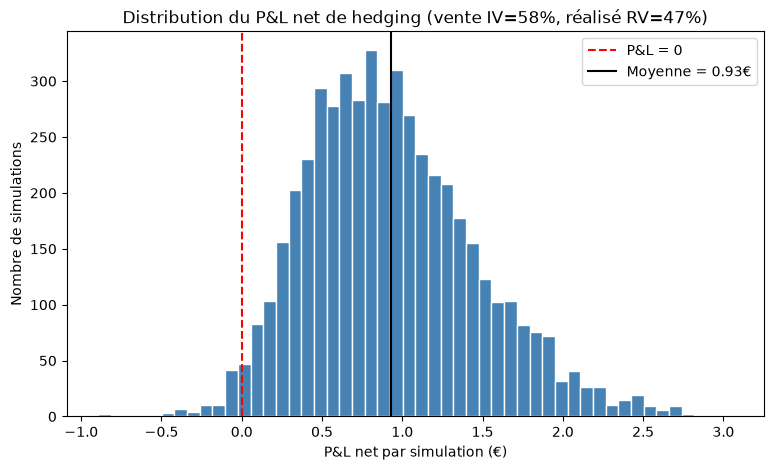

In [76]:
plt.figure(figsize=(9, 5))
plt.hist(net_pnl_per_sim, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='P&L = 0')
plt.axvline(mean_pnl, color='black', linestyle='-', label=f'Moyenne = {mean_pnl:.2f}€')
plt.title("Distribution du P&L net de hedging (vente IV=58%, réalisé RV=47%)")
plt.xlabel("P&L net par simulation (€)")
plt.ylabel("Nombre de simulations")
plt.legend()
plt.savefig("fig3_hedge_pnl_iv_high.png", dpi=150, bbox_inches='tight')
plt.show()

In [77]:
## Vente à RV Historique et paths simulés à IV pour comparer

In [78]:
paths_inv = simulate_daily_paths(spot_price, r, implied_vol, n_days_hedge, n_sims_hedge, seed=42)  # réalité: 58%

deltas_inv = bs_delta(paths_inv[:, :-1], 50, T_remaining_grid, r, rv_historical)  # hedge calculé à 47%
deltas_inv = np.hstack([deltas_inv, np.where(paths_inv[:, -1:] > 50, 1.0, 0.0)])

option_values_inv = bs_call_price(paths_inv[:, :-1], 50, T_remaining_grid, r, rv_historical)  # vendu à 47%
payoff_final_inv = np.maximum(paths_inv[:, -1:] - 50, 0)
option_values_inv = np.hstack([option_values_inv, payoff_final_inv])

stock_pnl_inv = deltas_inv[:, :-1] * np.diff(paths_inv, axis=1)
option_pnl_inv = -np.diff(option_values_inv, axis=1)
net_pnl_inv = (stock_pnl_inv + option_pnl_inv).sum(axis=1)

mean_pnl_inv = net_pnl_inv.mean()
se_pnl_inv = net_pnl_inv.std() / np.sqrt(n_sims_hedge)
print(f"P&L net moyen (vendu 47%, réalisé 58%): {mean_pnl_inv:.4f}")
print(f"IC 95%: [{mean_pnl_inv - 1.96*se_pnl_inv:.4f}, {mean_pnl_inv + 1.96*se_pnl_inv:.4f}]")
print(f"% de scénarios où le P&L net est positif: {(net_pnl_inv > 0).mean()*100:.1f}%")

P&L net moyen (vendu 47%, réalisé 58%): -0.6488
IC 95%: [-0.6655, -0.6322]
% de scénarios où le P&L net est positif: 10.2%


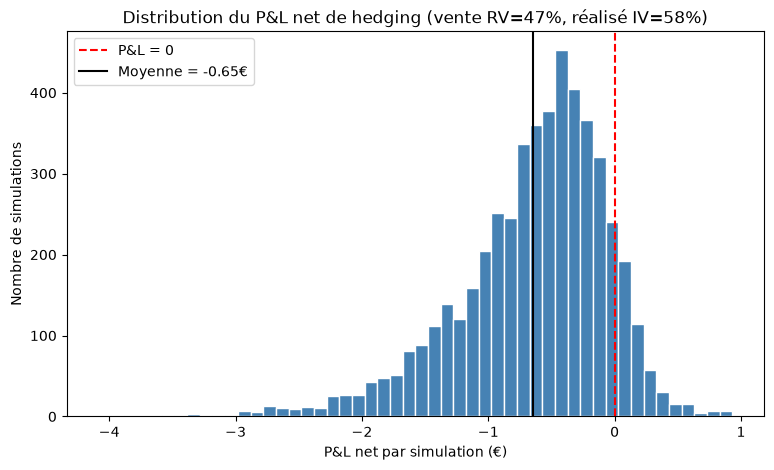

In [79]:
plt.figure(figsize=(9, 5))
plt.hist(net_pnl_inv, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='P&L = 0')
plt.axvline(mean_pnl_inv, color='black', linestyle='-', label=f'Moyenne = {mean_pnl_inv:.2f}€')
plt.title("Distribution du P&L net de hedging (vente RV=47%, réalisé IV=58%)")
plt.xlabel("P&L net par simulation (€)")
plt.ylabel("Nombre de simulations")
plt.legend()
plt.savefig("fig4_hedge_pnl_iv_low.png", dpi=150, bbox_inches='tight')
plt.show()

In [80]:
## Phase 5B - Backtesting du Delta-Hedging sur données historiques STM

In [81]:
stm_prices = close_prices.values  # conversion de la Series pandas en tableau numpy, pour rester cohérent avec paths_rv

window_start = 500  # point de départ arbitraire dans l'historique, à ajuster ensuite
real_path = stm_prices[window_start : window_start + n_days_hedge + 1]

print(f"Nombre de prix dans la fenêtre: {len(real_path)}")
print(f"Prix initial: {real_path[0]:.2f}, prix final: {real_path[-1]:.2f}")

Nombre de prix dans la fenêtre: 77
Prix initial: 42.98, prix final: 47.03


In [82]:
real_deltas = compute_delta_path(real_path, 50, r, implied_vol, n_days_hedge)
real_option_values = compute_option_value_path(real_path, 50, r, implied_vol, n_days_hedge)

real_stock_pnl = compute_hedge_pnl(real_path, real_deltas, n_days_hedge)
real_option_pnl = -np.diff(real_option_values)

real_net_pnl = (real_stock_pnl + real_option_pnl).sum()

print(f"Prime encaissée à la vente (jour 0): {real_option_values[0]:.4f}")
print(f"P&L net réel du hedge sur cette fenêtre: {real_net_pnl:.4f}")
print(f"P&L net moyen attendu par le modèle (Phase 5A, IV=58%/RV=47%): {mean_pnl:.4f}")

Prime encaissée à la vente (jour 0): 2.1168
P&L net réel du hedge sur cette fenêtre: 2.2113
P&L net moyen attendu par le modèle (Phase 5A, IV=58%/RV=47%): 0.9304


In [83]:
window_size = n_days_hedge + 1  # 77 jours par fenêtre
n_windows = len(stm_prices) // window_size
window_pnls = []

for w in range(n_windows):
    start = w * window_size
    path_w = stm_prices[start : start + window_size]
    deltas_w = compute_delta_path(path_w, 50, r, implied_vol, n_days_hedge)
    values_w = compute_option_value_path(path_w, 50, r, implied_vol, n_days_hedge)
    stock_pnl_w = compute_hedge_pnl(path_w, deltas_w, n_days_hedge)
    option_pnl_w = -np.diff(values_w)
    window_pnls.append((stock_pnl_w + option_pnl_w).sum())

window_pnls = np.array(window_pnls)
print(f"Nombre de fenêtres testées: {n_windows}")
print(f"P&L moyen sur les fenêtres réelles: {window_pnls.mean():.4f}")
print(f"% de fenêtres avec P&L positif: {(window_pnls > 0).mean()*100:.1f}%")

Nombre de fenêtres testées: 16
P&L moyen sur les fenêtres réelles: 0.3599
% de fenêtres avec P&L positif: 75.0%


In [84]:
se_window = window_pnls.std() / np.sqrt(n_windows)
ci_low_w, ci_high_w = window_pnls.mean() - 1.96*se_window, window_pnls.mean() + 1.96*se_window
print(f"Erreur-type sur les 16 fenêtres: {se_window:.4f}")
print(f"IC 95% du P&L réel: [{ci_low_w:.4f}, {ci_high_w:.4f}]")

Erreur-type sur les 16 fenêtres: 0.2706
IC 95% du P&L réel: [-0.1706, 0.8904]


In [85]:
## Phase 5C - Bande de tolérance de rebalancement ; arbitrage transaction costs vs qualité couverture

In [86]:
def hedge_with_threshold(path, K, r, sigma, n_days, threshold, cost_rate):
    T_remaining = (n_days - np.arange(n_days)) / 365
    theo_deltas = bs_delta(path[:-1], K, T_remaining, r, sigma)
    theo_deltas = np.append(theo_deltas, 1.0 if path[-1] > K else 0.0)

    held_delta = 0.0      # ce qu'on détient réellement en portefeuille
    total_pnl = 0.0
    n_trades = 0

    for t in range(n_days):
        # 1. gain/perte du jour sur ce qu'on détient déjà
        daily_gain = held_delta * (path[t+1] - path[t])
        total_pnl += daily_gain

        # 2. on regarde si on doit réajuster
        gap = theo_deltas[t+1] - held_delta
        last_day = (t == n_days - 1)

        if abs(gap) > threshold or last_day:
            transaction_cost = cost_rate * abs(gap) * path[t+1]
            total_pnl -= transaction_cost
            held_delta = theo_deltas[t+1]
            n_trades += 1

    return total_pnl, n_trades

In [87]:
test_pnl, test_n_trades = hedge_with_threshold(real_path, 50, r, implied_vol, n_days_hedge, threshold=0.0, cost_rate=0.001)
print(f"P&L (seuil=0, coût 0,1%): {test_pnl:.4f}, nb de trades: {test_n_trades}")

P&L (seuil=0, coût 0,1%): -0.1455, nb de trades: 76


In [88]:
stride = 5  # on avance de 5 jours entre deux fenêtres, au lieu de 77 (chevauchement volontaire)
starts = range(0, len(stm_prices) - window_size, stride)

thresholds_fine = np.arange(0.0, 0.31, 0.01)
threshold_results_fine = {th: [] for th in thresholds_fine}

for start in starts:
    path_w = stm_prices[start : start + window_size]
    values_w = compute_option_value_path(path_w, 50, r, implied_vol, n_days_hedge)
    option_pnl_w = -np.diff(values_w).sum()

    for th in thresholds_fine:
        stock_pnl_w, _ = hedge_with_threshold(path_w, 50, r, implied_vol, n_days_hedge, th, cost_rate=0.001)
        threshold_results_fine[th].append(stock_pnl_w + option_pnl_w)

mean_pnls_fine = [np.mean(threshold_results_fine[th]) for th in thresholds_fine]
best_th = thresholds_fine[np.argmax(mean_pnls_fine)]
print(f"Nombre de fenêtres utilisées (chevauchantes): {len(starts)}")
print(f"Seuil optimal trouvé: {best_th:.2f}, P&L moyen associé: {max(mean_pnls_fine):.4f}")

Nombre de fenêtres utilisées (chevauchantes): 236
Seuil optimal trouvé: 0.10, P&L moyen associé: 0.4361


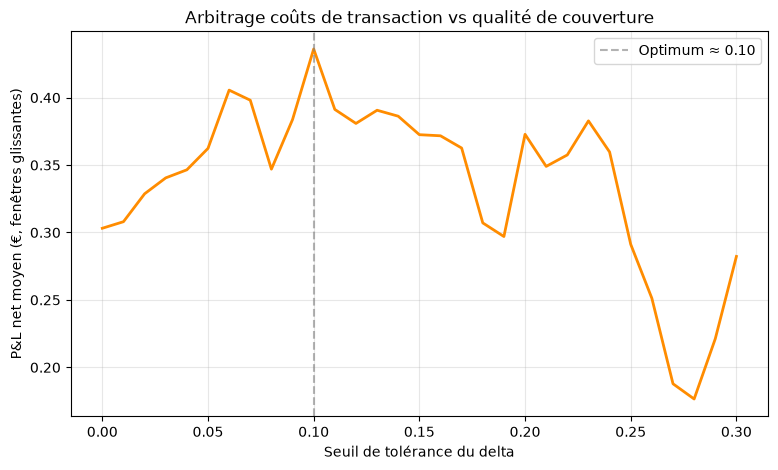

In [89]:
plt.figure(figsize=(9, 5))
plt.plot(thresholds_fine, mean_pnls_fine, color='darkorange', linewidth=2)
plt.axvline(best_th, color='gray', linestyle='--', alpha=0.6, label=f'Optimum ≈ {best_th:.2f}')
plt.title("Arbitrage coûts de transaction vs qualité de couverture")
plt.xlabel("Seuil de tolérance du delta")
plt.ylabel("P&L net moyen (€, fenêtres glissantes)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("fig5_hedge_threshold_arbitrage.png", dpi=150, bbox_inches='tight')
plt.show()